In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

clinical = pd.read_csv(f"../dataset/created/clinical_filtered/clinical.csv")
clinical.head()

,patientID,sex,age,AJCC_stage,M_stage,LDH,PFS_status,PFS_month,drug,BOR,BRAF_mut,brain_metastasis,immunotherapy_treatment,pre_MAPKi_treatment,source
0,BS_000,male,56,IV,NaN,normal,1.0,30.5,dabrafenib + trametinib,PD,V600E,no,no,no,Blateau et al.
1,BS_001,male,86,IV,NaN,normal,0.0,24.1,dabrafenib,SD,V600E,no,no,no,Blateau et al.
2,BS_002,female,47,IV,NaN,normal,0.0,14.1,dabrafenib + trametinib,CR,V600E,no,no,no,Blateau et al.
3,BS_003,female,50,IV,NaN,NaN,1.0,1.6,vemurafenib,PD,V600E,no,no,no,Blateau et al.
4,BS_004,female,47,IV,NaN,elevated,1.0,11.9,dabrafenib + trametinib,PD,V600K,no,no,no,Blateau et al.


In [9]:
clinical.isna().sum()

patientID                    0
sex                          0
age                          0
AJCC_stage                   0
M_stage                    137
LDH                        143
PFS_status                   2
PFS_month                    0
drug                         1
BOR                          7
BRAF_mut                     0
brain_metastasis           175
immunotherapy_treatment      0
pre_MAPKi_treatment          0
source                       0
dtype: int64

In [5]:
def get_pfs_label(row):
    months = row['PFS_month']
    event = row['PFS_status']
    
    if months >= 18:
        return 2  # Long responder
    elif months < 6 and event == 1:
        return 0   # Non responder
    elif 6 <= months < 18 and event == 1:
        return 1 # Intermediate
    else:
        return np.nan   # Undetermind
    
clinical['pfs_label'] = clinical.apply(get_pfs_label, axis=1)

y = clinical['pfs_label']
x = clinical.drop(['patientID', 'PFS_status', 'PFS_month', 'pfs_label'], axis=1)
x.head()

,sex,age,AJCC_stage,M_stage,LDH,drug,BOR,BRAF_mut,brain_metastasis,immunotherapy_treatment,pre_MAPKi_treatment
0,male,56,IV,NaN,normal,dabrafenib + trametinib,PD,V600E,no,no,no
1,male,86,IV,NaN,normal,dabrafenib,SD,V600E,no,no,no
2,female,47,IV,NaN,normal,dabrafenib + trametinib,CR,V600E,no,no,no
3,female,50,IV,NaN,NaN,vemurafenib,PD,V600E,no,no,no
4,female,47,IV,NaN,elevated,dabrafenib + trametinib,PD,V600K,no,no,no


In [6]:
drug_dummies = x['drug'].str.get_dummies(sep='+')
x = pd.concat([x.drop('drug', axis=1), drug_dummies], axis=1)
x

,sex,age,AJCC_stage,M_stage,LDH,BOR,BRAF_mut,brain_metastasis,immunotherapy_treatment,pre_MAPKi_treatment,cobimetinib,trametinib,dabrafenib,dabrafenib,vemurafenib,vemurafenib
0,male,56,IV,NaN,normal,PD,V600E,no,no,no,0,1,0,1,0,0
1,male,86,IV,NaN,normal,SD,V600E,no,no,no,0,0,1,0,0,0
2,female,47,IV,NaN,normal,CR,V600E,no,no,no,0,1,0,1,0,0
3,female,50,IV,NaN,NaN,PD,V600E,no,no,no,0,0,0,0,1,0
4,female,47,IV,NaN,elevated,PD,V600K,no,no,no,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
412,male,47,IV,M1C,NaN,PR,V600E,no,no,no,0,0,0,0,1,0
413,male,39,IV,M1A,NaN,PR,V600E,no,no,no,0,0,0,0,1,0
414,male,84,IV,M1C,NaN,PR,V600E,no,no,no,0,0,1,0,0,0
415,female,41,IV,M1C,NaN,PR,V600E,no,no,no,0,0,0,0,1,0


In [7]:
braf_mut_dummies = x['BRAF_mut'].str.get_dummies(sep=';')
x = pd.concat([x.drop('BRAF_mut', axis=1), braf_mut_dummies], axis=1)
x

,sex,age,AJCC_stage,M_stage,LDH,BOR,brain_metastasis,immunotherapy_treatment,pre_MAPKi_treatment,cobimetinib,...,dabrafenib,vemurafenib,vemurafenib,C195W,K601I,R558Q,MND,V600E,V600K,V600R
0,male,56,IV,NaN,normal,PD,no,no,no,0,...,1,0,0,0,0,0,0,1,0,0
1,male,86,IV,NaN,normal,SD,no,no,no,0,...,0,0,0,0,0,0,0,1,0,0
2,female,47,IV,NaN,normal,CR,no,no,no,0,...,1,0,0,0,0,0,0,1,0,0
3,female,50,IV,NaN,NaN,PD,no,no,no,0,...,0,1,0,0,0,0,0,1,0,0
4,female,47,IV,NaN,elevated,PD,no,no,no,0,...,1,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
412,male,47,IV,M1C,NaN,PR,no,no,no,0,...,0,1,0,0,0,0,0,1,0,0
413,male,39,IV,M1A,NaN,PR,no,no,no,0,...,0,1,0,0,0,0,0,1,0,0
414,male,84,IV,M1C,NaN,PR,no,no,no,0,...,0,0,0,0,0,0,0,1,0,0
415,female,41,IV,M1C,NaN,PR,no,no,no,0,...,0,1,0,0,0,0,0,1,0,0


In [8]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer

m_stage_prep = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=[['M1A', 'M1B', 'M1C']],
        handle_unknown='use_encoded_value',
        unknown_value=np.nan
    )),
])

bor_prep = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=[['PD', 'SD', 'PR', 'CR']],
        handle_unknown='use_encoded_value',
        unknown_value=np.nan
    )),
])

other_feat_prep = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('one_hot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('1', m_stage_prep, ['M_stage']),
    ('2', bor_prep, ['BOR']),
    ('3', other_feat_prep, ['sex', 'AJCC_stage', 'LDH', 'brain_metastasis', 'immunotherapy_treatment', 'pre_MAPKi_treatment'])
], remainder='passthrough')

preprocessor.set_output(transform='pandas')

x_processed = preprocessor.fit_transform(x)
x_processed.head()

,1__M_stage,2__BOR,3__sex_female,3__sex_male,3__AJCC_stage_IIIC,3__AJCC_stage_IV,3__LDH_elevated,3__LDH_normal,3__brain_metastasis_no,3__brain_metastasis_yes,...,remainder__dabrafenib,remainder__vemurafenib,remainder__vemurafenib,remainder__ C195W,remainder__ K601I,remainder__ R558Q,remainder__MND,remainder__V600E,remainder__V600K,remainder__V600R
0,2.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,1,0,0,0,0,0,0,1,0,0
1,2.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,0,0,0,0,0,0,0,1,0,0
2,2.0,3.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,...,1,0,0,0,0,0,0,1,0,0
3,2.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,...,0,1,0,0,0,0,0,1,0,0
4,2.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,...,1,0,0,0,0,0,0,0,1,0


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.model_selection import RepeatedStratifiedKFold

mask = y.notna()
x_clean = x_processed[mask]
y_clean = y[mask].astype(int)

clf = RandomForestClassifier(random_state=42)
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
rfecv = RFECV(estimator=clf, cv=rskf, scoring='balanced_accuracy', n_jobs=-1)
rfecv.fit(x_clean, y_clean)

print('Optimal number of features :', rfecv.n_features_)
print('Best features :', x_clean.columns[rfecv.support_])

Optimal number of features : 2
Best features : Index(['2__BOR', 'remainder__age'], dtype='object')


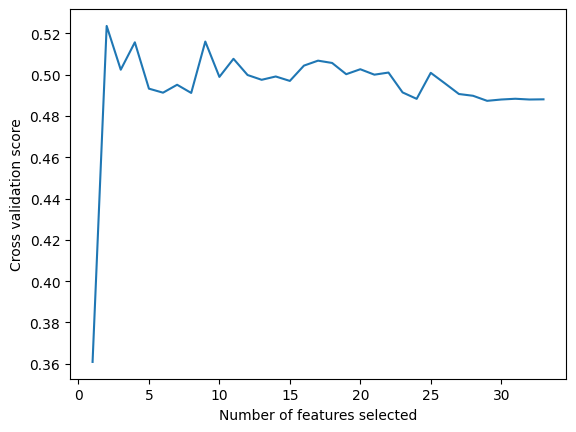

In [10]:
scores = rfecv.cv_results_['mean_test_score']
plt.xlabel("Number of features selected")
plt.ylabel("Cross validation score")
plt.plot(range(1, len(scores) + 1), scores)
plt.show()

In [11]:
ranking_df = pd.DataFrame({'feature': x_clean.columns, 'rank': rfecv.ranking_}).sort_values('rank')

ranking_df

,feature,rank
1,2__BOR,1
19,remainder__age,1
23,remainder__dabrafenib,2
0,1__M_stage,3
2,3__sex_female,4
7,3__LDH_normal,5
24,remainder__vemurafenib,6
8,3__brain_metastasis_no,7
30,remainder__V600E,8
11,3__immunotherapy_treatment_yes,9


In [12]:
x_transformed = rfecv.transform(x_clean)
x_transformed

array([[ 0., 56.],
       [ 1., 86.],
       [ 0., 50.],
       [ 0., 47.],
       [ 0., 53.],
       [ 0., 67.],
       [ 0., 65.],
       [ 0., 52.],
       [ 0., 63.],
       [ 0., 69.],
       [ 0., 42.],
       [ 0., 67.],
       [ 0., 61.],
       [ 0., 42.],
       [ 0., 24.],
       [ 0., 75.],
       [ 0., 42.],
       [ 0., 54.],
       [ 0., 70.],
       [ 0., 51.],
       [ 0., 42.],
       [ 0., 75.],
       [ 0., 43.],
       [ 0., 57.],
       [ 0., 73.],
       [ 0., 81.],
       [ 0., 71.],
       [ 0., 36.],
       [ 0., 89.],
       [ 0., 84.],
       [ 0., 25.],
       [ 0., 67.],
       [ 0., 71.],
       [ 0., 64.],
       [ 0., 60.],
       [ 0., 62.],
       [ 0., 87.],
       [ 0., 69.],
       [ 0., 85.],
       [ 0., 21.],
       [ 0., 32.],
       [ 2., 52.],
       [ 1., 53.],
       [ 3., 41.],
       [ 2., 41.],
       [ 2., 45.],
       [ 3., 36.],
       [ 2., 75.],
       [ 2., 38.],
       [ 1., 73.],
       [ 2., 68.],
       [ 2., 60.],
       [ 2.,

In [13]:
len(x_transformed)

361

In [14]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from xgboost import XGBClassifier
from tqdm import tqdm

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


models = {
    # 'LogisticRegression': LogisticRegression(max_iter=1000),
    # 'SVM': SVC(kernel='linear'),
    # 'DecisionTree': DecisionTreeClassifier(random_state=42),
    # 'RandomForest': RandomForestClassifier(random_state=42),
    # 'GradientBoosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

for name, model in tqdm(models.items(), desc='Models'):

    cv_results = cross_validate(
        estimator=model,
        X=x_transformed,
        y=y_clean,
        cv=rskf,
        scoring='balanced_accuracy',
        n_jobs=-1
    )
    
    mean = cv_results['test_score'].mean()
    std = cv_results['test_score'].std()
    print(f"{name}: {mean:.3f} ± {std:.3f}\n")
    
    y_pred = cross_val_predict(model, x_transformed, y_clean, cv=skf)
    print(classification_report(y_clean, y_pred))
    
    

Models:   0%|          | 0/1 [00:00<?, ?it/s]

XGBoost: 0.531 ± 0.054



Models: 100%|██████████| 1/1 [00:01<00:00,  1.69s/it]

              precision    recall  f1-score   support

           0       0.74      0.80      0.77       209
           1       0.51      0.46      0.48       119
           2       0.41      0.33      0.37        33

    accuracy                           0.65       361
   macro avg       0.55      0.53      0.54       361
weighted avg       0.64      0.65      0.64       361



In [15]:

for name, model in tqdm(models.items(), desc='Models'):

    cv_results = cross_validate(
        estimator=model,
        X=x_clean,
        y=y_clean,
        cv=rskf,
        scoring='balanced_accuracy',
        n_jobs=-1
    )
    
    mean = cv_results['test_score'].mean()
    std = cv_results['test_score'].std()
    print(f"{name}: {mean:.3f} ± {std:.3f}\n")
    
    y_pred = cross_val_predict(model, x_clean, y_clean, cv=skf)
    print(classification_report(y_clean, y_pred))
    
    

Models:   0%|          | 0/1 [00:00<?, ?it/s]

XGBoost: 0.525 ± 0.067



Models: 100%|██████████| 1/1 [00:01<00:00,  1.86s/it]

              precision    recall  f1-score   support

           0       0.74      0.77      0.75       209
           1       0.47      0.50      0.49       119
           2       0.47      0.27      0.35        33

    accuracy                           0.63       361
   macro avg       0.56      0.51      0.53       361
weighted avg       0.63      0.63      0.63       361



In [16]:
x_transformed_df = pd.DataFrame(x_transformed, columns=rfecv.get_feature_names_out())
x_transformed_df['pfs_label'] = y
x_transformed_df.to_csv('dataset/clinical_rfe.csv', index=False)